In [1]:
from pathlib import Path
import yaml
import os 
os.chdir(Path('/gpfs-calypso/home/globc/garcia/'))
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import glob
import numpy as np
import xarray as xr
from scipy import stats


from scenarIA.src.data.dataloader import get_climatology
from scenarIA.src.utils.evalutils import EvaluationPlots, compare_temporal_profiles, compare_metrics_maps, compare_metrics
from scenarIA.src.utils.datautils import dataset_xr_formatting, weighted_global_mean
from scenarIA.src.utils.settings import PREDICTIONS_DIR, DATASET_DIR, GRAPHS_DIR, CONFIG_DIR, SIMUS_COLORS_DICT

with open(CONFIG_DIR / 'plots.yaml') as file:
    config_plots = yaml.safe_load(file)

/softs/Anaconda/2024.02-1/envs/gloenv_py3.11/lib/python3.12/site-packages/pyproj/__init__.py:91: UserWarning: Valid PROJ data directory not found. Either set the path using the environmental variable PROJ_DATA (PROJ 9.1+) | PROJ_LIB (PROJ<9.1) or with `pyproj.datadir.set_data_dir`.
  warnings.warn(str(err))


## Benchmark

Same dataset, different methods

In [25]:
var_name = 'pr'
#save_dir = GRAPHS_DIR/ f'runs/MPI-ESM1-2-LR/annual/exp9' # or None
save_dir = None
pred_path = PREDICTIONS_DIR / f'MPI-ESM1-2-LR/annual/exp9'
title_base = 'MPI-ESM1-2-LR_annual_exp9_benchmarkv4'
relative_changes=False
if relative_changes :
    simus_dict = {'ssp245': {'color': 'royalblue',
                        'mean_error': [-10., 10.],
                        'values': [-40., 40.],
                        'std': [0, 600.]},
            'ssp370': {'color': 'red',
                        'mean_error': [-1, 1],
                        'values': [-2.4, 2.4],
                        'std': [0, 0.3]}}
else:
    simus_dict = {'pr':{'ssp245': {'color': 'royalblue',
                            'mean_error': [-0.6, 0.6],
                            'values': [-2.4, 2.4],
                            'std': [0, 0.25]},
                        'ssp370': {'color': 'red',
                            'mean_error': [-1, 1],
                            'values': [-2.4, 2.4],
                            'std': [0, 0.3]}},
                  'tas':{'ssp245': {'color': 'royalblue',
                            'mean_error': [-0.6, 0.6],
                            'values': [0, 7.5],
                            'std': [0, 0.3]},
                        'ssp370': {'color': 'red',
                            'mean_error': [-1, 1],
                            'values': [-2.4, 2.4],
                            'std': [0, 0.3]}}}


# Open climatology file
clim_simu = 'piControl'
clim = xr.open_dataset(DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_{clim_simu}.nc').mean('member')
if clim_simu == 'piControl':  
    clim = clim.sel(time=slice('1850-01-01', '2250-12-31')).mean('time')[var_name].values
else:
    clim = clim.sel(time=slice('1994-01-01', '2014-12-31')).mean('time')[var_name].values

In [26]:
true_simu = 'ssp245'

In [36]:
mini_dict = simus_dict[var_name][true_simu]
title = title_base + f'_{true_simu}'

config_plots[var_name]['lim']['mean_error'] = mini_dict['mean_error']
config_plots[var_name]['lim']['values'] = mini_dict['values']
config_plots[var_name]['lim']['std'] = mini_dict['std']
#if relative_changes:
    #config_plots[var_name]['unit'] = '%' 

color = mini_dict['color']

# Open true projection file
true = xr.open_dataset( DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_{true_simu}.nc').mean('member') # 50 members
lats = true.lat.values
t = true.time.values
y = true[var_name].values

# Open prediction files to compare
#y_hat_dict = {'CNN-LSTM': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_cnn-lstm_seq5_mem30_epoch100_bs4_clim.nc')[var_name].values,
#        'CNN-GRU': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_cnn-gru_seq5_mem30_epoch100_bs4_clim.nc')[var_name].values,
#        'ConvLSTM': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_convlstm_seq5_mem30_epoch100_bs4_clim.nc')[var_name].values,
#        'ConvGRU': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_convgru_seq5_mem30_epoch100_bs4_clim.nc')[var_name].values,
#        'TrajGRU': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_trajgru_seq5_mem30_epoch100_bs4_clim.nc')[var_name].values,
#        'UNet': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_unet_seq5_mem30_epoch100_bs4_clim_64.nc')[var_name].values,
#        'Attention-UNet' : xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_attention-unet_seq5_mem30_epoch100_bs4_clim_64.nc')[var_name].values}
#        'Pattern-Scaling' : xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_pattern-scaling_seq1_mem30.nc')[var_name].values}

y_hat_dict = {
        'CNN-GRU': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_cnn-gru_seq5_mem30_epoch100_bs4_clim.nc')[var_name].values,
        'Attention-UNet' : xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_attention-unet_seq5_mem30_epoch100_bs4_clim_64.nc')[var_name].values,
        'Pattern-Scaling (4simus)': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_pattern-scaling_seq1_mem30_5simus.nc')[var_name].values,
        'Pattern-Scaling (7simus)' : xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_pattern-scaling_seq1_mem30.nc')[var_name].values}


y = y - clim
for test, y_hat in y_hat_dict.items():
    y_hat_dict[test] = y_hat - clim


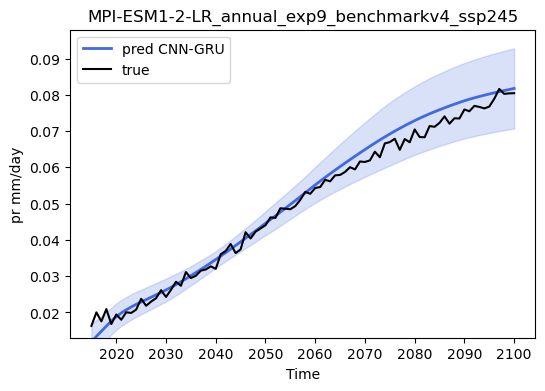

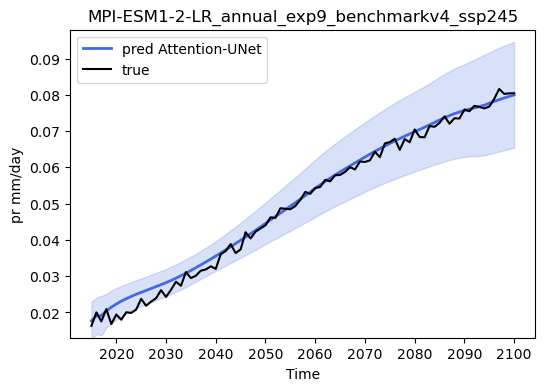

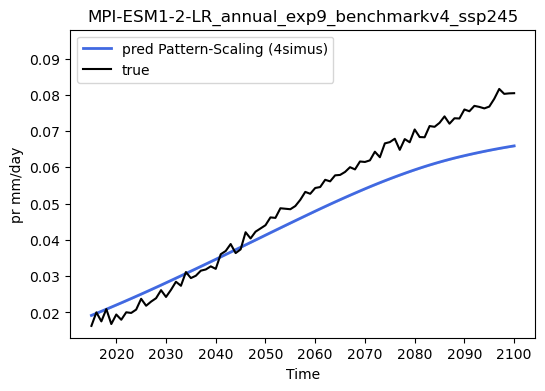

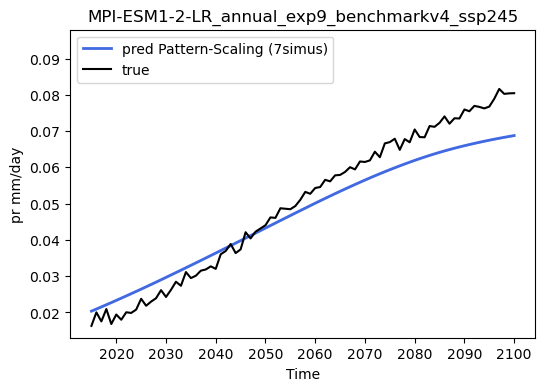

In [33]:
# clim changes 
for key, value in y_hat_dict.items():
    test_dict = {key:value}
    color_dict = {key: color}
    compare_temporal_profiles(y,
                              test_dict, 
                              t, 
                              var_name, 
                              lats, 
                              point=None, 
                              window_size=None, 
                              config_plots=config_plots, 
                              colors=color_dict, 
                              title=title, 
                              save_dir=save_dir)

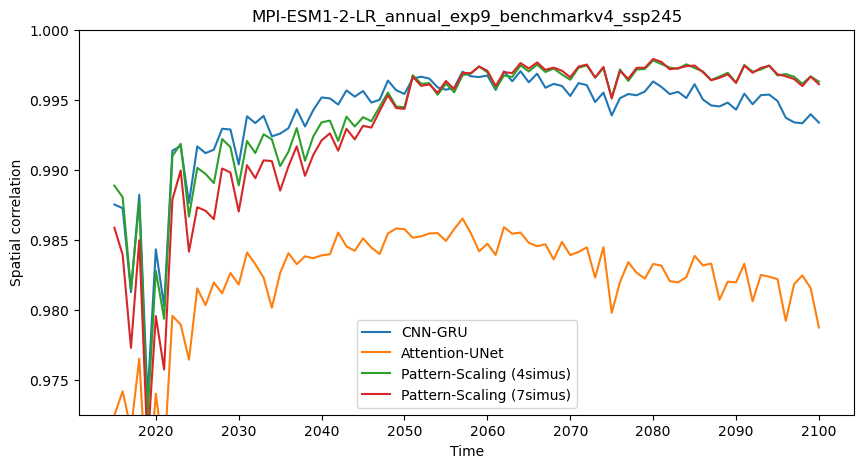

In [6]:
# Figure : Correlation spatiale

fig, ax1 = plt.subplots(figsize = (10,5))
for key, value in y_hat_dict.items():
    data = np.stack(value, axis=0)
    corr_list = []
    for run in range(data.shape[0]):
        data_seed = data[run]
        corr = [stats.pearsonr(y[i].flatten(), data_seed[i, ...].flatten()).statistic for i in range(y.shape[0])]
        corr_list.append(corr)
    corr_mean = np.stack(corr_list,axis=0).mean(axis=0)
    ax1.plot(t, corr_mean, label=key)
    ax1.set_title(title)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Spatial correlation')
    ax1.set_ylim(None,1)
ax1.legend()
if save_dir:
    fig.savefig(save_dir/f'{title}_spatial_correlation_{var_name}.png')

[-2.4  -1.92 -1.44 -0.96 -0.48  0.    0.48  0.96  1.44  1.92  2.4 ]
[0.    0.025 0.05  0.075 0.1   0.125 0.15  0.175 0.2   0.225 0.25 ]
[-0.6        -0.46666667 -0.33333333 -0.2        -0.06666667  0.06666667
  0.2         0.33333333  0.46666667  0.6       ]
[-1.         -0.77777778 -0.55555556 -0.33333333 -0.11111111  0.11111111
  0.33333333  0.55555556  0.77777778  1.        ]
[-2.4  -1.92 -1.44 -0.96 -0.48  0.    0.48  0.96  1.44  1.92  2.4 ]
[0.    0.025 0.05  0.075 0.1   0.125 0.15  0.175 0.2   0.225 0.25 ]
[-0.6        -0.46666667 -0.33333333 -0.2        -0.06666667  0.06666667
  0.2         0.33333333  0.46666667  0.6       ]
[-1.         -0.77777778 -0.55555556 -0.33333333 -0.11111111  0.11111111
  0.33333333  0.55555556  0.77777778  1.        ]
[-2.4  -1.92 -1.44 -0.96 -0.48  0.    0.48  0.96  1.44  1.92  2.4 ]
[0.    0.025 0.05  0.075 0.1   0.125 0.15  0.175 0.2   0.225 0.25 ]
[-0.6        -0.46666667 -0.33333333 -0.2        -0.06666667  0.06666667
  0.2         0.33333333  0

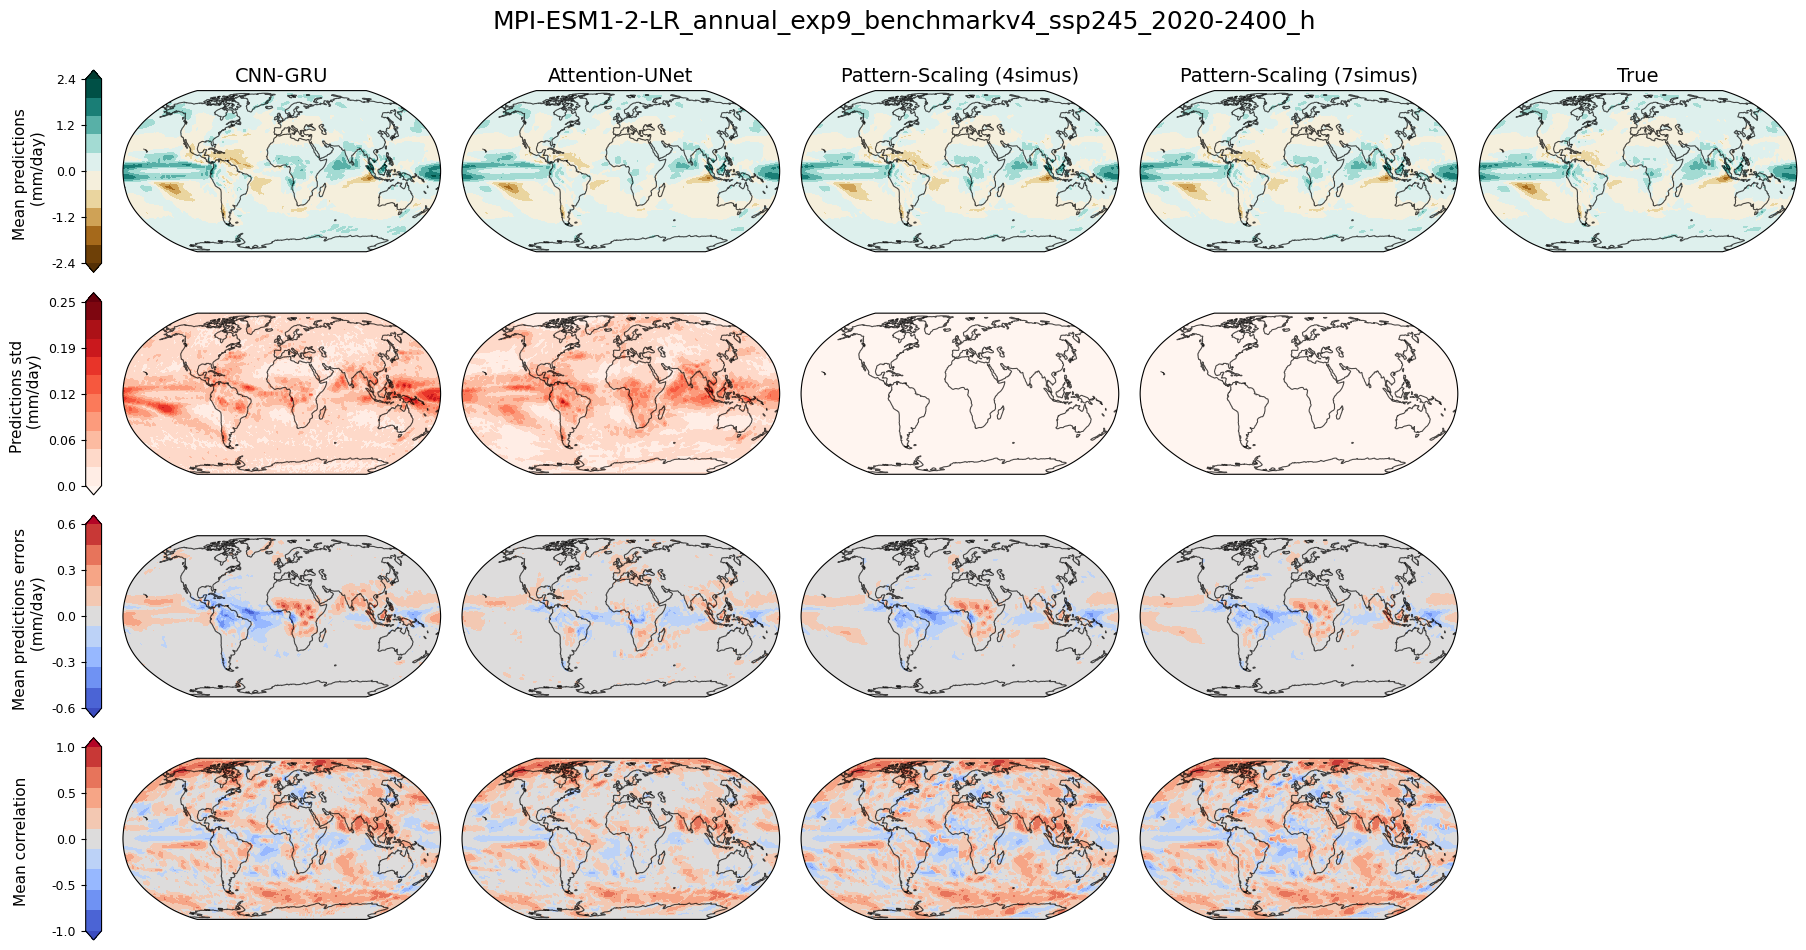

In [29]:
y_end = y[-21:, :, :]
for key, y_hat in y_hat_dict.items():
    y_hat_dict[key] = [i[-21:,:,:] for i in y_hat]
compare_metrics_maps(y_end, 
                    y_hat_dict, 
                    var_name=var_name, 
                    title=f'{title}_2020-2400_h', 
                    save_dir=save_dir,
                    config_plots=config_plots,
                    no_limits=False,
                    climatology=None,
                    relative_changes=relative_changes)

/gpfs-calypso/home/globc/garcia/scenarIA/src/utils/evalutils.py:656: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  metrics_values_mean  = [torch.tensor(metric_dict[metric][t]).mean().item()             for t in test_names]
/gpfs-calypso/home/globc/garcia/scenarIA/src/utils/evalutils.py:657: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  metrics_values_lower = [torch.tensor(metric_dict[metric][t]).quantile(0.025).item()    for t in test_names]
/gpfs-calypso/home/globc/garcia/scenarIA/src/utils/evalutils.py:658: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(

['CNN-GRU', 'Attention-UNet', 'Pattern-Scaling (4simus)', 'Pattern-Scaling (7simus)'] = [1.7956962117759177, 1.5331066775595021, 1.9160759862641041, 1.6910178504240252] with 95% CI [[1.3995215730269355, 1.1704108554216954, 1.9160759862641041, 1.6910178504240252], [2.3631790708859195, 2.179107119875096, 1.9160759862641041, 1.6910178504240252]]


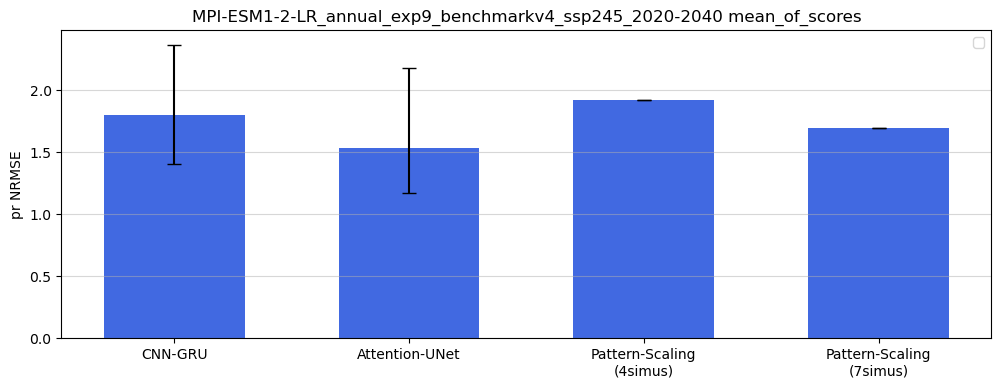

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['CNN-GRU', 'Attention-UNet', 'Pattern-Scaling (4simus)', 'Pattern-Scaling (7simus)'] = [1.4440425499275098, 1.188130494313752, 1.1053476677179568, 1.0604891073445695] with 95% CI [[1.2679625553944927, 1.0321860218442718, 1.1053476677179568, 1.0604891073445695], [1.6882647691946566, 1.3020636850141603, 1.1053476677179568, 1.0604891073445695]]


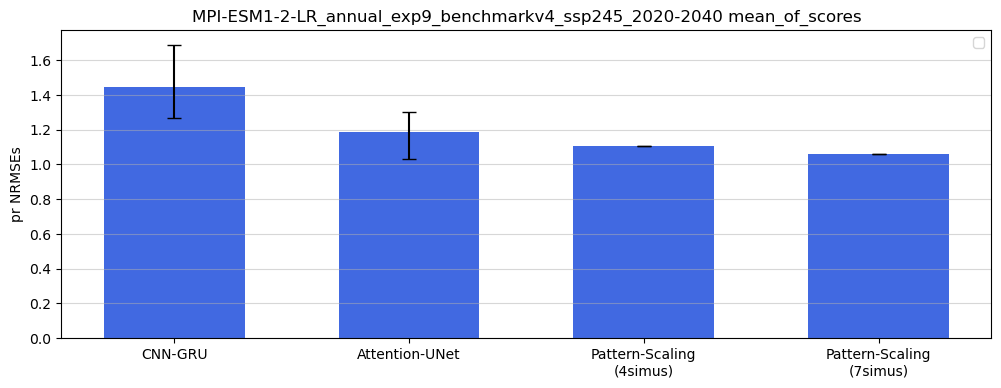

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['CNN-GRU', 'Attention-UNet', 'Pattern-Scaling (4simus)', 'Pattern-Scaling (7simus)'] = [0.07033073236968154, 0.06899523664915, 0.16214566370922948, 0.12610574861589113] with 95% CI [[0.02406675697301312, 0.02368173867037123, 0.16214566370922948, 0.12610574861589113], [0.14012726993679642, 0.18208755340223337, 0.16214566370922948, 0.12610574861589113]]


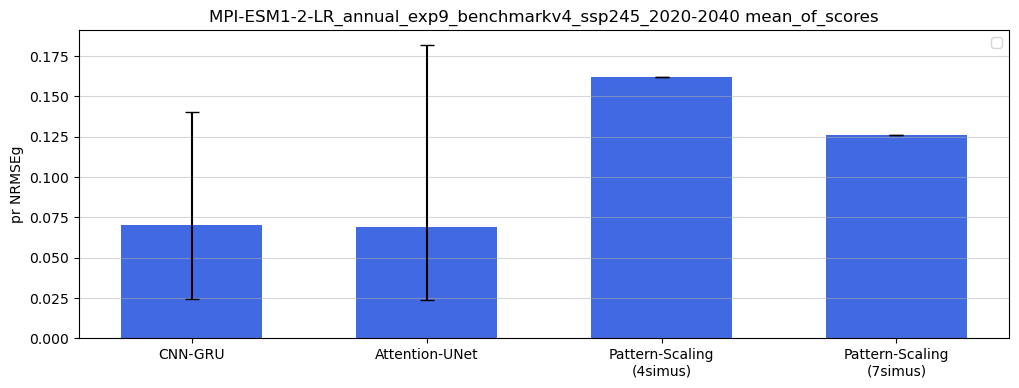

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['CNN-GRU', 'Attention-UNet', 'Pattern-Scaling (4simus)', 'Pattern-Scaling (7simus)'] = [0.10828112852637968, 0.08909163429246367, 0.08288418709026987, 0.07952048043111155] with 95% CI [[0.09507781916412371, 0.07739818144559711, 0.08288418709026987, 0.07952048043111155], [0.12659406363676898, 0.0976348828735188, 0.08288418709026987, 0.07952048043111155]]


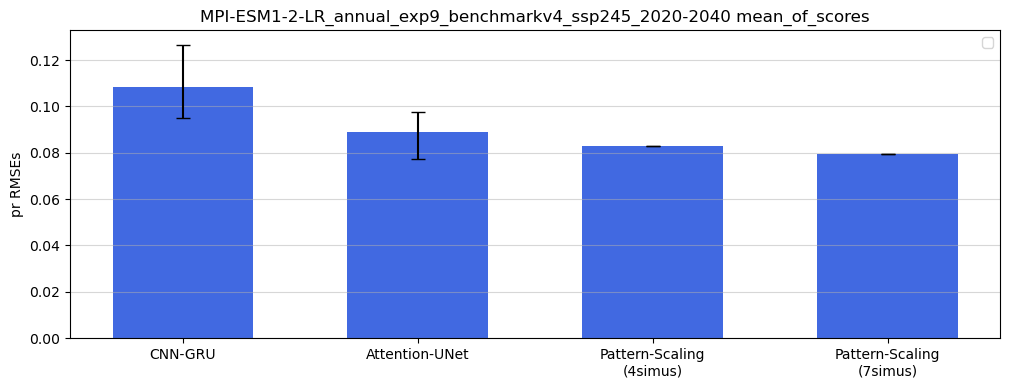

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['CNN-GRU', 'Attention-UNet', 'Pattern-Scaling (4simus)', 'Pattern-Scaling (7simus)'] = [0.005273730383816041, 0.005173588609068082, 0.012158447445316332, 0.00945600444701446] with 95% CI [[0.00180463907046146, 0.0017757685802425483, 0.012158447445316332, 0.00945600444701446], [0.010507404319103087, 0.013653784491316422, 0.012158447445316332, 0.00945600444701446]]


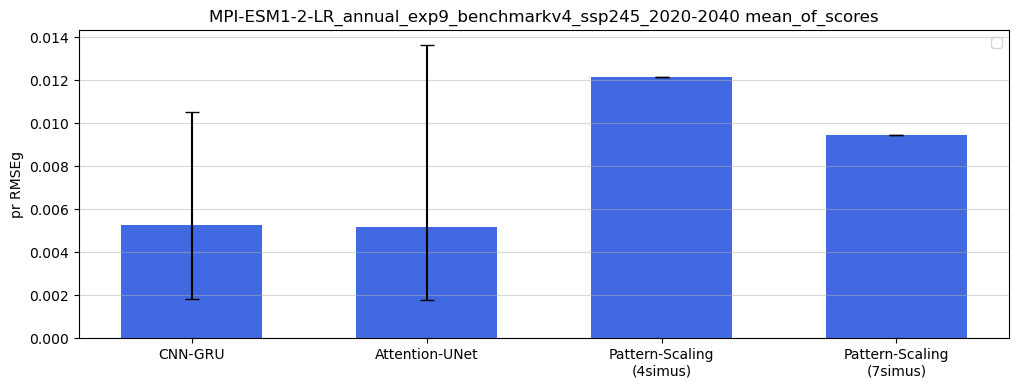

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['CNN-GRU', 'Attention-UNet', 'Pattern-Scaling (4simus)', 'Pattern-Scaling (7simus)'] = [0.9403030276298523, 0.9415497779846191, 0.9480254054069519, 0.9496927857398987] with 95% CI [[0.933213472366333, 0.9366193413734436, 0.9480254054069519, 0.9496927857398987], [0.9459994435310364, 0.9484953284263611, 0.9480254054069519, 0.9496927857398987]]


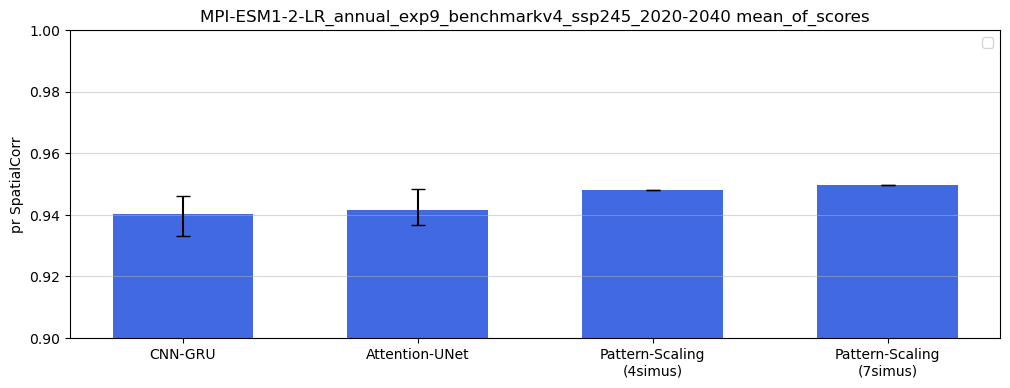

In [37]:
y_end = y[-21:, :, :] 
for key, y_hat in y_hat_dict.items():
    y_hat_dict[key] = [i[-21:,:,:] for i in y_hat]
compare_metrics(y_end, 
            y_hat_dict, 
            lats=lats, 
            var_name=var_name, 
            title=f'{title}_2020-2040', 
            save_dir=save_dir, 
            ensemble_scoring='mean_of_scores',
            figsize=(12,4),
            colors=color ,
            labels=None)